Reading EGI MFF Header from /Users/ylee885/Library/CloudStorage/OneDrive-SharedLibraries-GeorgiaInstituteofTechnology/Engle Lab - raw/19109_20250306_122357.mff...
    Reading events ...
    Assembling measurement info ...
    Excluding events {} ...
<RawMff | signal1.bin, 67 x 1309115 (1309.1 s), ~80 KiB, data not loaded>


/var/folders/1h/clz66k6s1n3f_89j69yskcm40000gr/T/ipykernel_44328/1993983339.py:14: RuntimeWarning: The unit for channel(s) VREF has changed from V to NA.
  raw.set_channel_types({'VREF': 'misc'})


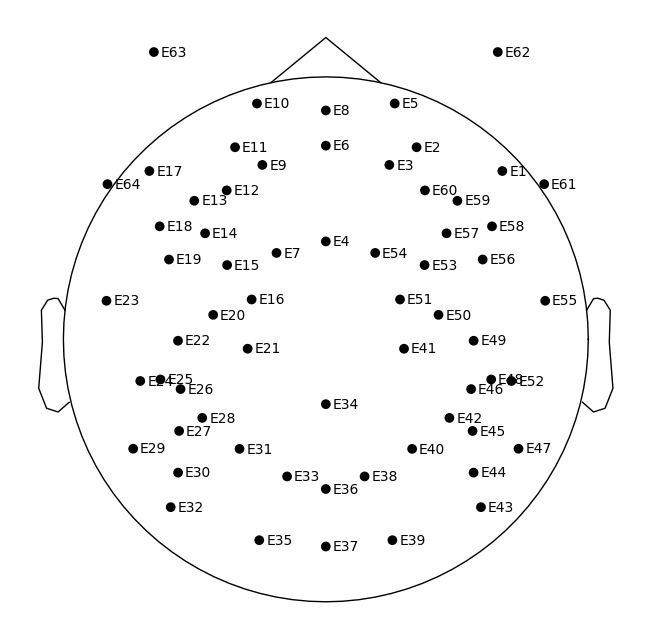

Number of channels: 67
['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10']


In [9]:
import mne
import matplotlib.pyplot as plt

# -------------------------------------------------
# Load raw mff
# -------------------------------------------------

file_path = '/Users/ylee885/Library/CloudStorage/OneDrive-SharedLibraries-GeorgiaInstituteofTechnology/Engle Lab - raw/19109_20250306_122357.mff'

raw = mne.io.read_raw_egi(file_path, preload=False)

print(raw)

raw.set_channel_types({'VREF': 'misc'})

montage = mne.channels.make_standard_montage("GSN-HydroCel-65_1.0")

raw.set_montage(montage)

raw.plot_sensors(show_names=True)
# -------------------------------------------------
# Set HydroCel 64 montage
# -------------------------------------------------

montage = mne.channels.make_standard_montage("GSN-HydroCel-64_1.0")

raw.set_montage(montage)

print("Number of channels:", len(raw.ch_names))
print(raw.ch_names[:10])

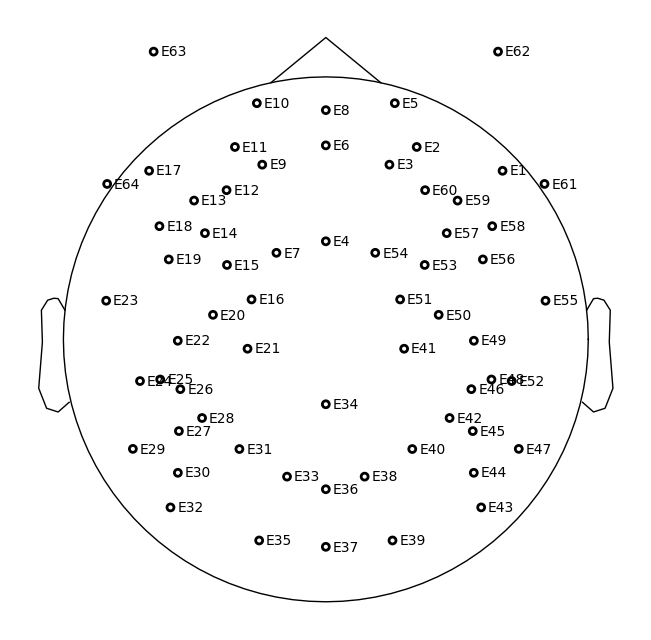

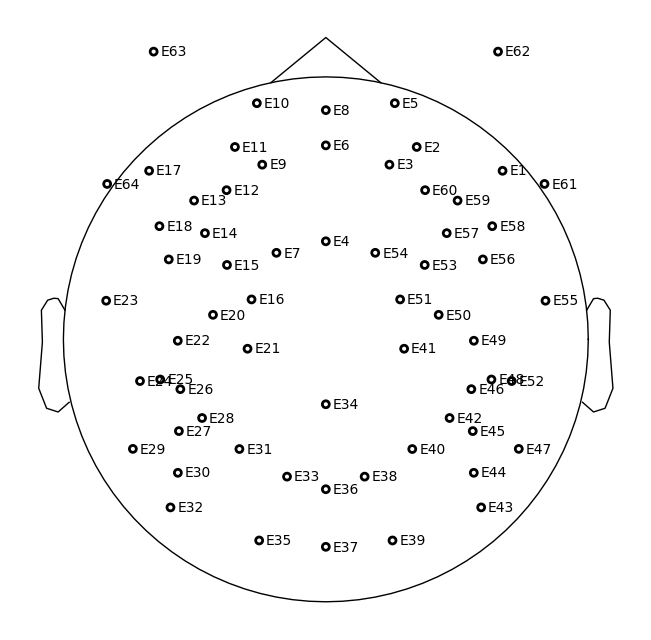

In [7]:
import mne

roi = {
    # frontopolar / prefrontal (좌우 + 약간 중앙)
    "prefrontal": ["E10", "E8", "E5", "E11", "E2"],

    # frontal (좌우 + midline)
    "frontal":    ["E9", "E6", "E3", "E12", "E60"],

    # central (sensorimotor 근처: 좌우 + 중앙)
    "central":    ["E20", "E4", "E50", "E16", "E54", "E51"],

    # temporal (lateral 쪽: 좌우)
    "left_temporal":  ["E18", "E14", "E15", "E22", "E23"],
    "right_temporal": ["E58", "E57", "E56", "E52", "E55"],

    # parietal (두정: 좌우 + 중앙)
    "parietal":   ["E31", "E34", "E42", "E28", "E41"],

    # posterior / occipital (후두: 좌우 + 중앙)
    "posterior":  ["E35", "E37", "E39", "E33", "E38", "E36"],
}

groups = list(roi.values())
mne.viz.plot_sensors(
    raw.info,
    kind="topomap",
    ch_groups=groups,
    show_names=True
)